<a href="https://colab.research.google.com/github/sadiq937/Shaik_DM/blob/main/PS5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## PS5 - DATAMANGEMENT

#Macro-Financial Analysis and Stock Price Forecasting: Exploring the Impact of Economic Indicators on Market Trends

📄 Abstract — Final Presentation (S5): Macro-Financial Analysis and Stock Price Forecasting
This project offers a comprehensive exploration of the dynamic relationship between key macroeconomic indicators and the stock market performance of major technology firms, specifically Apple and Nvidia. The goal is to understand how variables such as the S&P 500 Index, Consumer Price Index (CPI), Federal Funds Rate, Real GDP Growth Rate, and Unemployment Rate influence stock behavior over time, and how this relationship can be leveraged for predictive modeling.

Macroeconomic data is sourced via the Federal Reserve Economic Data (FRED) API, while historical monthly stock prices for Apple and Nvidia are retrieved using the Alpha Vantage API. This data is cleaned, merged, and transformed to analyze temporal trends and percentage changes. Using techniques like stacking/unstacking, long-format reshaping, and fuzzy matching (via the fuzzywuzzy package), we standardize indicator names and align data from disparate sources, ensuring consistency across the dataset.

The analysis employs interactive and insightful visualizations built with Plotly, including:

Correlation Heatmap to quantify relationships between economic indicators

Time-Series Line Plot for S&P 500 trend tracking

Scatter Plot showing CPI vs. Interest Rate interaction

Market Trend Bar Chart classifying market states as Boom, Downturn, or Stable based on S&P 500 volatility

Area Plot to highlight collective macroeconomic movements over time

In the advanced phase of this project, a deep learning-based Long Short-Term Memory (LSTM) model is developed to forecast future stock prices for Apple, using historical closing prices. The model is trained on 95% of the scaled data, with 60-day rolling windows, and tested on the remaining 5%. Forecast performance is evaluated using RMSE, and predictions are visualized against actual prices to assess trend capture and deviation.

The project further compares the performance of Apple and Nvidia by analyzing their return distributions and stock-specific responsiveness to macroeconomic factors. Feature importance from Random Forest models provides interpretability on which economic indicators most strongly influence stock returns.

By combining macro-level economic analysis with micro-level stock forecasting, this work bridges the gap between financial economics and machine learning. The findings demonstrate both the interpretability of macroeconomic influences on markets and the applicability of LSTM models for real-world stock forecasting. The study concludes with a critical reflection on the model's assumptions, limitations, and suggestions for future improvements such as integrating sentiment analysis, using multivariate LSTM models, and expanding stock coverage across multiple sectors.

## INSTALLING DEPENDENCIES

In [23]:
!pip install fuzzywuzzy

In [24]:
!pip install python-Levenshtein

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 161.7/161.7 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 27.4 MB/s eta 0:00:00


In [25]:
!pip install yfinance

In [90]:
!pip install tensorflow

In [178]:
import requests
import os
import pandas as pd
import numpy as np
import re
import time
import plotly.express as px
from fuzzywuzzy import fuzz
from fuzzywuzzy import process
import folium
from datetime import datetime
import seaborn as sns
import matplotlib.pyplot as plt
from io import StringIO
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.layers import Input, LSTM, Dropout, Dense, Bidirectional
from tensorflow.keras.models import Sequential, load_model
from keras.models import Sequential
from keras.layers import Dense, LSTM
import yfinance as yf
import requests
from io import StringIO
from google.colab import userdata
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

## LOADING DATASETS - API

In [167]:
FRED_API_KEY = userdata.get('FRED_API_KEY')
ALPHA_VANTAGE_API_KEY = userdata.get('ALPHA_VANTAGE_API_KEY')

# Function to fetch data from FRED
def fetch_fred_data(series_id, start_date="2000-01-01", end_date=str(datetime.today().date())):
    url = f"https://api.stlouisfed.org/fred/series/observations?series_id={series_id}&api_key={FRED_API_KEY}&file_type=json&observation_start={start_date}&observation_end={end_date}"
    response = requests.get(url).json()
    data = response.get("observations", [])
    return pd.DataFrame([{"date": obs["date"], series_id: float(obs["value"])} for obs in data if obs["value"] != "."])

In [168]:
# Function to fetch data from Alpha Vantage

def fetch_alpha_vantage_data(function, symbol, interval="Monthly", start_date="2000-01-01", end_date=str(datetime.today().date())):
    url = f"https://www.alphavantage.co/query?function={function}&symbol={symbol}&interval={interval}&apikey={ALPHA_VANTAGE_API_KEY}&datatype=csv"
    response = requests.get(url).text
    df = pd.read_csv(StringIO(response))
    df['timestamp'] = pd.to_datetime(df['timestamp'])
    df = df[(df['timestamp'] >= start_date) & (df['timestamp'] <= end_date)]
    return df[['timestamp', 'close']].rename(columns={'timestamp': 'date', 'close': symbol})

In [122]:
# Fetching stock data from Alpha Vantage API (APPLE)
ALPHA_VANTAGE_API_KEY = userdata.get('ALPHA_VANTAGE_API_KEY')
apple_stock_df = fetch_alpha_vantage_data("TIME_SERIES_MONTHLY", "AAPL")
apple_stock_df.head()

,date,AAPL
0,2025-04-28,210.14
1,2025-03-31,222.13
2,2025-02-28,241.84
3,2025-01-31,236.00
4,2024-12-31,250.42


In [123]:
# Fetching stock data from Alpha Vantage API (NVIDIA)
nvidia_stock_df = fetch_alpha_vantage_data("TIME_SERIES_MONTHLY", "NVDA")
nvidia_stock_df.head()

,date,NVDA
0,2025-04-28,108.73
1,2025-03-31,108.38
2,2025-02-28,124.92
3,2025-01-31,120.07
4,2024-12-31,134.29


## MERGING DATASETS

In [152]:
FRED_API_KEY = userdata.get('FRED_API_KEY')

def fetch_fred_data(series_id):
    url = f"https://api.stlouisfed.org/fred/series/observations?series_id={series_id}&api_key={FRED_API_KEY}&file_type=json"
    response = requests.get(url).json()
    data = response.get("observations", [])
    return pd.DataFrame([{"date": obs["date"], series_id: float(obs["value"])} for obs in data if obs["value"] != "."])

macro_indicators = {
    "SP500": "S&P 500",
    "CPIAUCSL": "CPI",
    "FEDFUNDS": "Federal Funds Rate",
    "A191RL1Q225SBEA": "REAL_GDP",
    "UNRATE": "UNEMP_RATE"
}

macro_df = None
for code in macro_indicators:
    df = fetch_fred_data(code)
    df.rename(columns={code: macro_indicators[code]}, inplace=True)  # ✅ inplace used here
    df["date"] = pd.to_datetime(df["date"])
    if macro_df is None:
        macro_df = df
    else:
        macro_df = pd.merge(macro_df, df, on="date", how="inner")

macro_df.set_index("date", inplace=True)
macro_pct_df = macro_df.pct_change().dropna()


In [153]:
macro_df.head()

,S&P 500,CPI,Federal Funds Rate,REAL_GDP,UNEMP_RATE
date,,,,,
2015-07-01,2077.42,238.034,0.13,1.6,5.2
2015-10-01,1923.82,237.733,0.12,0.7,5.0
2016-04-01,2072.78,238.992,0.37,1.3,5.1
2016-07-01,2102.95,240.101,0.39,2.9,4.8
2018-10-01,2924.59,252.772,2.19,0.6,3.8


In [155]:
macro_pct_df.head()

,S&P 500,CPI,Federal Funds Rate,REAL_GDP,UNEMP_RATE
date,,,,,
2015-10-01,-0.073938,-0.001265,-0.076923,-0.562500,-0.038462
2016-04-01,0.077429,0.005296,2.083333,0.857143,0.020000
2016-07-01,0.014555,0.004640,0.054054,1.230769,-0.058824
2018-10-01,0.390708,0.052774,4.615385,-0.793103,-0.208333
2019-04-01,-0.019627,0.009736,0.105023,4.666667,-0.026316


## STACK/ UNSTACK

In [156]:
long_format_df = pct_change_df.stack().reset_index()
long_format_df.columns = ["date", "indicator", "value"]
long_format_df.head()

,date,indicator,value
0,2015-10-01,SP500,-0.073938
1,2015-10-01,CPI,-0.001265
2,2015-10-01,FEDFUNDS,-0.076923
3,2015-10-01,Real_GDP,-0.5625
4,2015-10-01,UNEMP_RATE,-0.038462


## MARKET TREND CATEGORY

In [157]:
def categorize_market(value):
    if value > 0.02:
        return "Boom"
    elif value < -0.02:
        return "Downturn"
    else:
        return "Stable"

pct_change_df["Market_Trend"] = pct_change_df["SP500"].apply(categorize_market)
pct_change_df.head()

,SP500,CPI,FEDFUNDS,Real_GDP,UNEMP_RATE,Market_Trend
date,,,,,,
2015-10-01,-0.073938,-0.001265,-0.076923,-0.562500,-0.038462,Downturn
2016-04-01,0.077429,0.005296,2.083333,0.857143,0.020000,Boom
2016-07-01,0.014555,0.004640,0.054054,1.230769,-0.058824,Stable
2018-10-01,0.390708,0.052774,4.615385,-0.793103,-0.208333,Boom
2019-04-01,-0.019627,0.009736,0.105023,4.666667,-0.026316,Stable


## RESHAPE (PIVOT)

In [158]:
pivot_df = long_format_df.pivot(index="date", columns="indicator", values="value")
pivot_df.head()

indicator,CPI,FEDFUNDS,Market_Trend,Real_GDP,SP500,UNEMP_RATE
date,,,,,,
2015-10-01,-0.001265,-0.076923,Downturn,-0.5625,-0.073938,-0.038462
2016-04-01,0.005296,2.083333,Boom,0.857143,0.077429,0.02
2016-07-01,0.00464,0.054054,Stable,1.230769,0.014555,-0.058824
2018-10-01,0.052774,4.615385,Boom,-0.793103,0.390708,-0.208333
2019-04-01,0.009736,0.105023,Stable,4.666667,-0.019627,-0.026316


## CORRELATION MATRIX

In [159]:
numerical_df = pct_change_df.select_dtypes(include=['number'])
correlation_matrix_df = numerical_df.corr()
correlation_matrix_df

,SP500,CPI,FEDFUNDS,Real_GDP,UNEMP_RATE
SP500,1.000000,0.679210,0.368073,-0.035030,-0.396294
CPI,0.679210,1.000000,0.720566,0.179440,-0.275009
FEDFUNDS,0.368073,0.720566,1.000000,0.379848,-0.291805
Real_GDP,-0.035030,0.179440,0.379848,1.000000,-0.723314
UNEMP_RATE,-0.396294,-0.275009,-0.291805,-0.723314,1.000000


## VISUALIZATIONS

In [160]:
fig1 = px.imshow(correlation_matrix_df, text_auto=True, color_continuous_scale='RdBu_r', title="Correlation Between Macroeconomic Indicators")
fig1.show()


## TREND OF S&P 500 over time

In [161]:
df_reset = pct_change_df.reset_index()
fig2 = px.line(df_reset, x="date", y="SP500", title="S&P 500 Trend Over Time", labels={"SP500": "S&P 500 Returns"})
fig2.show()

## Inflation vs interest rate

In [162]:

# Scatter plot of Inflation vs. Interest Rates
fig3 = px.scatter(df_reset, x="CPI", y="FEDFUNDS", title="Inflation vs. Interest Rates", labels={"CPIAUCSL": "Inflation (CPI)", "FEDFUNDS": "Interest Rate"}, trendline="ols")
fig3.show()


## MARKET TREND BAR CHART

In [163]:
# Bar chart for market trend categories
market_trend_counts_df = pct_change_df["Market_Trend"].value_counts().reset_index()
market_trend_counts_df.columns = ["Trend", "Count"]
fig4 = px.bar(market_trend_counts_df, x="Trend", y="Count", title="Market Trend Distribution", color="Trend")
fig4.show()

## MACROECONOMIC INDICATORS OVER TIME

In [164]:
# Time-series area plot
fig5 = px.area(df_reset, x="date", y=["SP500", "CPI", "FEDFUNDS", "Real_GDP", "UNEMP_RATE"], title="Macroeconomic Indicators Over Time", labels={"value": "Percentage Change", "variable": "Indicator"})
fig5.show()

## FUZZYWUZZY

In [165]:
fuzzy_data_df = pd.DataFrame({"Indicator_Names": ["CPI", "FEDFunds Rate", "SP 500", "CPI", "AAPL Stock"]})

def match_indicator_name(indicator_name):
    threshold = 50

    # Check similarity ratios for each comparison
    similarity_score_cpi = fuzz.ratio(indicator_name, "Consumer Price Index")
    similarity_score_fed = fuzz.ratio(indicator_name, "Federal Funds Rate")
    similarity_score_sp500 = fuzz.ratio(indicator_name, "S&P 500 Index")
    similarity_score_apple = fuzz.ratio(indicator_name, "Apple Stock")

    # Print similarity scores for each match attempt
    print(f"Matching '{indicator_name}' with 'Consumer Price Index' gives score: {similarity_score_cpi}")
    print(f"Matching '{indicator_name}' with 'Federal Funds Rate' gives score: {similarity_score_fed}")
    print(f"Matching '{indicator_name}' with 'S&P 500 Index' gives score: {similarity_score_sp500}")
    print(f"Matching '{indicator_name}' with 'Apple Stock' gives score: {similarity_score_apple}")

    # Determine the best match based on the highest similarity score
    if similarity_score_cpi > threshold:
        return "Consumer Price Index"
    elif similarity_score_fed > threshold:
        return "Federal Funds Rate"
    elif similarity_score_sp500 > threshold:
        return "S&P 500 Index"
    elif similarity_score_apple > threshold:
        return "Apple Stock"
    else:
        return indicator_name

fuzzy_data_df["Matched_Names"] = fuzzy_data_df["Indicator_Names"].apply(match_indicator_name)
fuzzy_data_df

Matching 'CPI' with 'Consumer Price Index' gives score: 26
Matching 'CPI' with 'Federal Funds Rate' gives score: 0
Matching 'CPI' with 'S&P 500 Index' gives score: 25
Matching 'CPI' with 'Apple Stock' gives score: 0
Matching 'FEDFunds Rate' with 'Consumer Price Index' gives score: 24
Matching 'FEDFunds Rate' with 'Federal Funds Rate' gives score: 71
Matching 'FEDFunds Rate' with 'S&P 500 Index' gives score: 23
Matching 'FEDFunds Rate' with 'Apple Stock' gives score: 17
Matching 'SP 500' with 'Consumer Price Index' gives score: 15
Matching 'SP 500' with 'Federal Funds Rate' gives score: 8
Matching 'SP 500' with 'S&P 500 Index' gives score: 63
Matching 'SP 500' with 'Apple Stock' gives score: 12
Matching 'CPI' with 'Consumer Price Index' gives score: 26
Matching 'CPI' with 'Federal Funds Rate' gives score: 0
Matching 'CPI' with 'S&P 500 Index' gives score: 25
Matching 'CPI' with 'Apple Stock' gives score: 0
Matching 'AAPL Stock' with 'Consumer Price Index' gives score: 13
Matching 'AAPL 

,Indicator_Names,Matched_Names
0,CPI,CPI
1,FEDFunds Rate,Federal Funds Rate
2,SP 500,S&P 500 Index
3,CPI,CPI
4,AAPL Stock,Apple Stock


In [63]:
tech_list = ['AAPL', 'NVDA' ,'GOOG', 'MSFT', 'AMZN']
end = datetime.now()
start = datetime(end.year - 10, end.month, end.day)

stock_data = {}
for symbol in tech_list:
    stock_data[symbol] = yf.download(symbol, start=start, end=end)

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


In [64]:
for symbol in tech_list:
    # Use 'Close' instead of 'Adj Close' if it exists, otherwise use 'Adj Close'
    close_col = 'Close' if 'Close' in stock_data[symbol].columns else 'Adj Close'
    stock_data[symbol]['MA20'] = stock_data[symbol][close_col].rolling(20).mean()
    stock_data[symbol]['Daily Return'] = stock_data[symbol][close_col].pct_change()

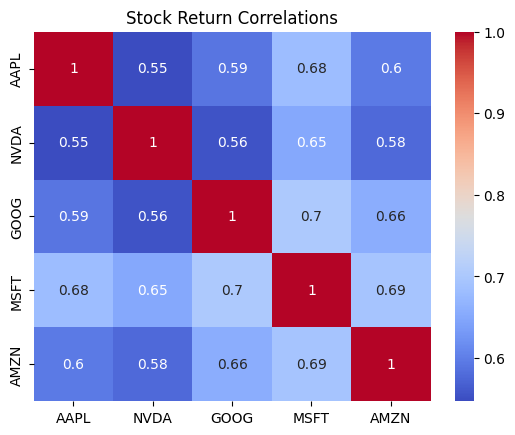

In [65]:
closing_df = pd.concat([stock_data[s]['Close'] for s in tech_list], axis=1)
closing_df.columns = tech_list
returns_df = closing_df.pct_change().dropna()
sns.heatmap(returns_df.corr(), annot=True, cmap='coolwarm')
plt.title("Stock Return Correlations")
plt.show()


In [172]:
apple_df = stock_data['AAPL'][['Close']]

apple_values = apple_df.values
training_data_len = int(np.ceil(len(apple_values) * 0.95))

scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(apple_values)
train_data = scaled_data[:training_data_len, :]

x_train, y_train = [], []
for i in range(60, len(train_data)):
    x_train.append(train_data[i-60:i, 0])
    y_train.append(train_data[i, 0])

x_train, y_train = np.array(x_train), np.array(y_train)
x_train = np.reshape(x_train, (x_train.shape[0], x_train.shape[1], 1))

model = Sequential([
    Input(shape=(x_train.shape[1], 1)),   # 👈 Explicit input layer
    LSTM(128, return_sequences=True),
    LSTM(64),
    Dense(25),
    Dense(1)
])
model.compile(optimizer='adam', loss='mean_squared_error')
model.fit(x_train, y_train, batch_size=1, epochs=1)


2331/2331 ━━━━━━━━━━━━━━━━━━━━ 118s 49ms/step - loss: 0.0058


3/4 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step 

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 196ms/step


<ipython-input-173-30ff87168287>:12: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



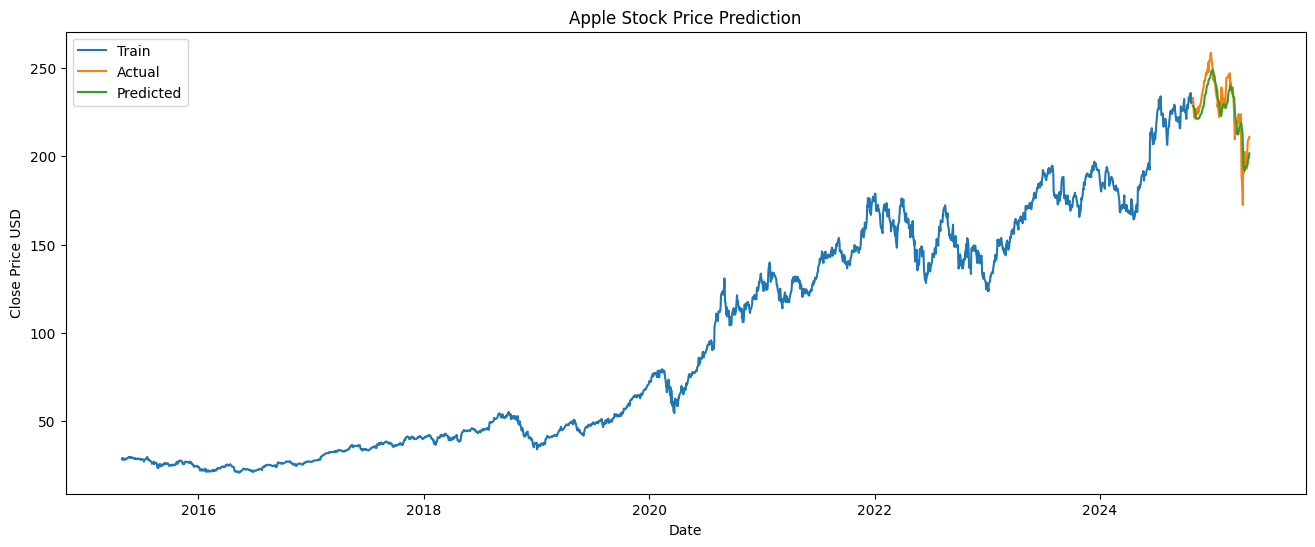

In [173]:
test_data = scaled_data[training_data_len - 60:]
x_test = []
for i in range(60, len(test_data)):
    x_test.append(test_data[i-60:i, 0])

x_test = np.array(x_test)
x_test = np.reshape(x_test, (x_test.shape[0], x_test.shape[1], 1))
predictions = model.predict(x_test)
predictions = scaler.inverse_transform(predictions)

valid = apple_df.iloc[training_data_len:]
valid['Predictions'] = predictions

plt.figure(figsize=(16,6))
plt.title('Apple Stock Price Prediction')
plt.plot(apple_df['Close'][:training_data_len], label='Train')
plt.plot(valid[['Close']], label='Actual')
plt.plot(valid[['Predictions']], label='Predicted')
plt.legend()
plt.xlabel('Date')
plt.ylabel('Close Price USD')
plt.show()

Epoch 1/50
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step - loss: 0.1532

46/46 ━━━━━━━━━━━━━━━━━━━━ 11s 147ms/step - loss: 0.1511 - val_loss: 0.0100
Epoch 2/50
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step - loss: 0.0081

46/46 ━━━━━━━━━━━━━━━━━━━━ 9s 112ms/step - loss: 0.0081 - val_loss: 0.0071
Epoch 3/50
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step - loss: 0.0057

46/46 ━━━━━━━━━━━━━━━━━━━━ 10s 110ms/step - loss: 0.0057 - val_loss: 0.0069
Epoch 4/50
46/46 ━━━━━━━━━━━━━━━━━━━━ 6s 135ms/step - loss: 0.0052 - val_loss: 0.0089
Epoch 5/50
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step - loss: 0.0055 

46/46 ━━━━━━━━━━━━━━━━━━━━ 9s 115ms/step - loss: 0.0055 - val_loss: 0.0065
Epoch 6/50
46/46 ━━━━━━━━━━━━━━━━━━━━ 11s 124ms/step - loss: 0.0052 - val_loss: 0.0069
Epoch 7/50
46/46 ━━━━━━━━━━━━━━━━━━━━ 10s 114ms/step - loss: 0.0044 - val_loss: 0.0075
Epoch 8/50
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step - loss: 0.0041

...

46/46 ━━━━━━━━━━━━━━━━━━━━ 10s 141ms/step - loss: 0.0039 - val_loss: 0.0057
Epoch 11/50
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step - loss: 0.0044

46/46 ━━━━━━━━━━━━━━━━━━━━ 9s 107ms/step - loss: 0.0044 - val_loss: 0.0054
Epoch 12/50
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - loss: 0.0040

46/46 ━━━━━━━━━━━━━━━━━━━━ 7s 139ms/step - loss: 0.0040 - val_loss: 0.0053
Epoch 13/50
46/46 ━━━━━━━━━━━━━━━━━━━━ 5s 108ms/step - loss: 0.0038 - val_loss: 0.0108
Epoch 14/50
46/46 ━━━━━━━━━━━━━━━━━━━━ 6s 137ms/step - loss: 0.0034 - val_loss: 0.0077
Epoch 15/50
46/46 ━━━━━━━━━━━━━━━━━━━━ 5s 109ms/step - loss: 0.0040 - val_loss: 0.0092
Epoch 16/50
46/46 ━━━━━━━━━━━━━━━━━━━━ 7s 143ms/step - loss: 0.0035 - val_loss: 0.0126
Epoch 17/50
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step - loss: 0.0039 

46/46 ━━━━━━━━━━━━━━━━━━━━ 5s 111ms/step - loss: 0.0039 - val_loss: 0.0049
Epoch 18/50
46/46 ━━━━━━━━━━━━━━━━━━━━ 6s 130ms/step - loss: 0.0033 - val_loss: 0.0056
Epoch 19/50
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step - loss: 0.0030

46/46 ━━━━━━━━━━━━━━━━━━━━ 6s 118ms/step - loss: 0.0030 - val_loss: 0.0045
Epoch 20/50
46/46 ━━━━━━━━━━━━━━━━━━━━ 5s 112ms/step - loss: 0.0030 - val_loss: 0.0105
Epoch 21/50
46/46 ━━━━━━━━━━━━━━━━━━━━ 10s 112ms/step - loss: 0.0029 - val_loss: 0.0046
Epoch 22/50
46/46 ━━━━━━━━━━━━━━━━━━━━ 10s 110ms/step - loss: 0.0030 - val_loss: 0.0064
Epoch 23/50
46/46 ━━━━━━━━━━━━━━━━━━━━ 6s 128ms/step - loss: 0.0027 - val_loss: 0.0085
Epoch 24/50
46/46 ━━━━━━━━━━━━━━━━━━━━ 9s 109ms/step - loss: 0.0027 - val_loss: 0.0059


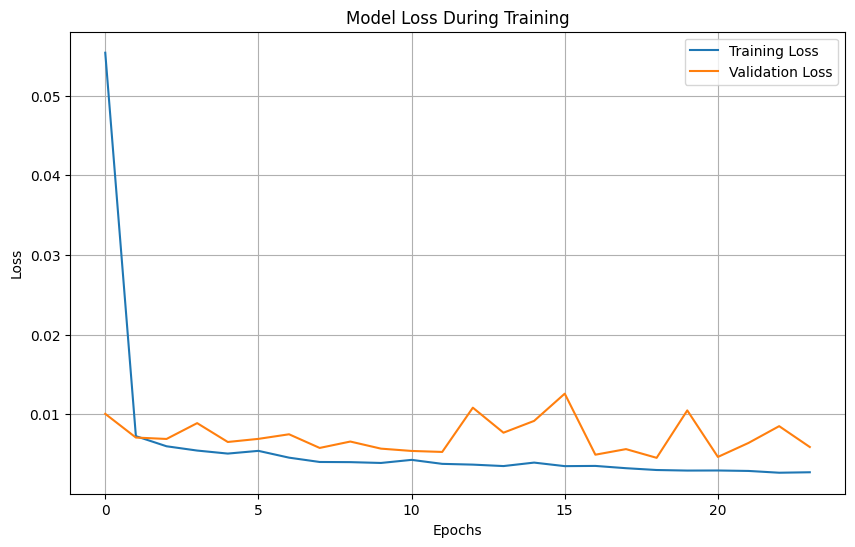

In [176]:
apple_values = apple_df[['Close']].values

# ⚖️ Z-Score Normalization
scaler = StandardScaler()
scaled_data = scaler.fit_transform(apple_values)

# 📊 Split into Train (60%), Val (20%), Test (20%)
total_len = len(scaled_data)
train_len = int(total_len * 0.60)
val_len = int(total_len * 0.20)
test_len = total_len - train_len - val_len

train_data = scaled_data[:train_len]
val_data = scaled_data[train_len:train_len+val_len]
test_data = scaled_data[train_len+val_len:]

# 🪟 Create 60-Day Sequences
def create_sequences(data, window_size=60):
    X, y = [], []
    for i in range(window_size, len(data)):
        X.append(data[i-window_size:i, 0])
        y.append(data[i, 0])
    return np.array(X), np.array(y)

x_train, y_train = create_sequences(train_data)
x_val, y_val = create_sequences(val_data)
x_test, y_test = create_sequences(test_data)

# 🔄 Reshape for LSTM (samples, time_steps, features)
x_train = np.reshape(x_train, (x_train.shape[0], x_train.shape[1], 1))
x_val = np.reshape(x_val, (x_val.shape[0], x_val.shape[1], 1))
x_test = np.reshape(x_test, (x_test.shape[0], x_test.shape[1], 1))

# 🧠 Build LSTM Model
model = Sequential([
    Input(shape=(x_train.shape[1], 1)),
    LSTM(128, return_sequences=True),
    Dropout(0.2),
    LSTM(64),
    Dropout(0.2),
    Dense(25),
    Dense(1)
])

model.compile(optimizer='adam', loss='mean_squared_error')

# ⏳ Early Stopping & Model Saving
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
model_save = ModelCheckpoint('best_model.h5', monitor='val_loss', save_best_only=True)

# 🎯 Train Model
history = model.fit(
    x_train, y_train,
    epochs=50,
    batch_size=32,
    validation_data=(x_val, y_val),
    callbacks=[early_stop, model_save],
    verbose=1
)

# 📈 Plot Loss Curves
plt.figure(figsize=(10,6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss During Training')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid()
plt.show()




14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 59ms/step
Test Set RMSE: 11.41835


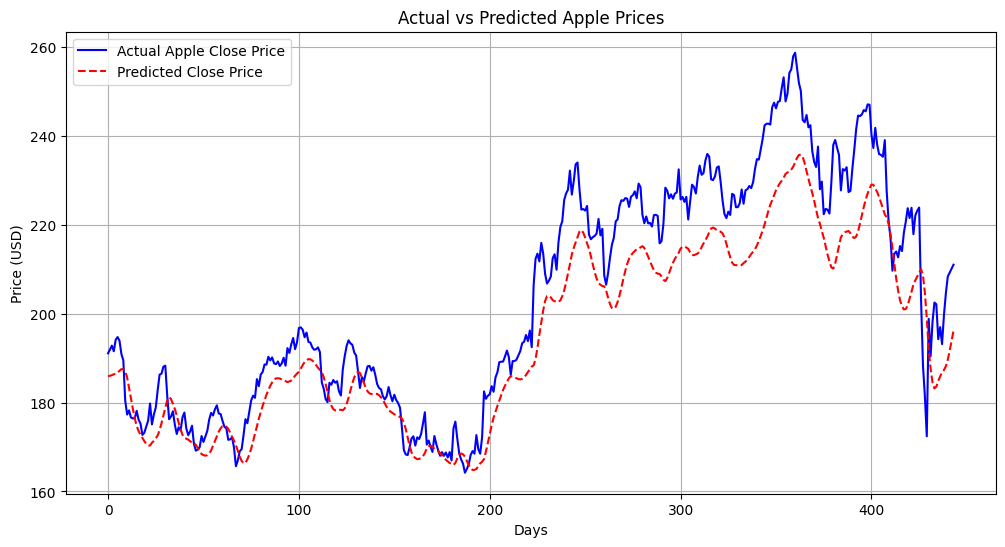

In [177]:
# 💾 Load Best Model (optional - if you restart runtime)
# from tensorflow.keras.models import load_model
# model = load_model('best_model.h5')

# 🔍 Evaluate on Test Set
predictions = model.predict(x_test)

# Inverse transform (if you want actual price range)
predictions_unscaled = scaler.inverse_transform(predictions)
y_test_unscaled = scaler.inverse_transform(y_test.reshape(-1,1))

# 📊 Test RMSE
rmse = np.sqrt(mean_squared_error(y_test_unscaled, predictions_unscaled))
print(f"Test Set RMSE: {rmse:.5f}")

# 📉 Plot Actual vs Predicted
plt.figure(figsize=(12,6))
plt.plot(y_test_unscaled, label='Actual Apple Close Price', color='blue')
plt.plot(predictions_unscaled, label='Predicted Close Price', color='red', linestyle='--')
plt.title('Actual vs Predicted Apple Prices')
plt.xlabel('Days')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid()
plt.show()

In [206]:
end = datetime.now()
start = datetime(end.year - 10, end.month, end.day)
apple_df = yf.download('AAPL', start=start, end=end)
apple_df.dropna(inplace=True)
apple_df = apple_df[['Open', 'High', 'Low', 'Close', 'Volume']]

scaler = StandardScaler()
scaled_data = scaler.fit_transform(apple_df)

## 🔀 Split Dataset (60/20/20)
total_len = len(scaled_data)
train_len = int(total_len * 0.60)
val_len = int(total_len * 0.20)
test_len = total_len - train_len - val_len

train_data = scaled_data[:train_len]
val_data = scaled_data[train_len:train_len+val_len]
test_data = scaled_data[train_len+val_len:]

## 🪟 Create 60-Day Sequences
def create_sequences(data, window_size=60):
    X, y = [], []
    for i in range(window_size, len(data)):
        X.append(data[i-window_size:i])
        y.append(data[i, 3])  # Predict 'Close' column (index 3)
    return np.array(X), np.array(y)

x_train, y_train = create_sequences(train_data)
x_val, y_val = create_sequences(val_data)
x_test, y_test = create_sequences(test_data)


[*********************100%***********************]  1 of 1 completed


Epoch 1/50
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 212ms/step - loss: 0.1248

46/46 ━━━━━━━━━━━━━━━━━━━━ 20s 258ms/step - loss: 0.1232 - val_loss: 0.0071 - learning_rate: 0.0010
Epoch 2/50
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 176ms/step - loss: 0.0095

46/46 ━━━━━━━━━━━━━━━━━━━━ 18s 206ms/step - loss: 0.0095 - val_loss: 0.0057 - learning_rate: 0.0010
Epoch 3/50
46/46 ━━━━━━━━━━━━━━━━━━━━ 11s 212ms/step - loss: 0.0072 - val_loss: 0.0069 - learning_rate: 0.0010
Epoch 4/50
46/46 ━━━━━━━━━━━━━━━━━━━━ 11s 235ms/step - loss: 0.0060 - val_loss: 0.0083 - learning_rate: 0.0010
Epoch 5/50
46/46 ━━━━━━━━━━━━━━━━━━━━ 26s 350ms/step - loss: 0.0066 - val_loss: 0.0108 - learning_rate: 0.0010
Epoch 6/50
46/46 ━━━━━━━━━━━━━━━━━━━━ 14s 200ms/step - loss: 0.0058 - val_loss: 0.0079 - learning_rate: 5.0000e-04
Epoch 7/50
46/46 ━━━━━━━━━━━━━━━━━━━━ 12s 241ms/step - loss: 0.0049 - val_loss: 0.0080 - learning_rate: 5.0000e-04


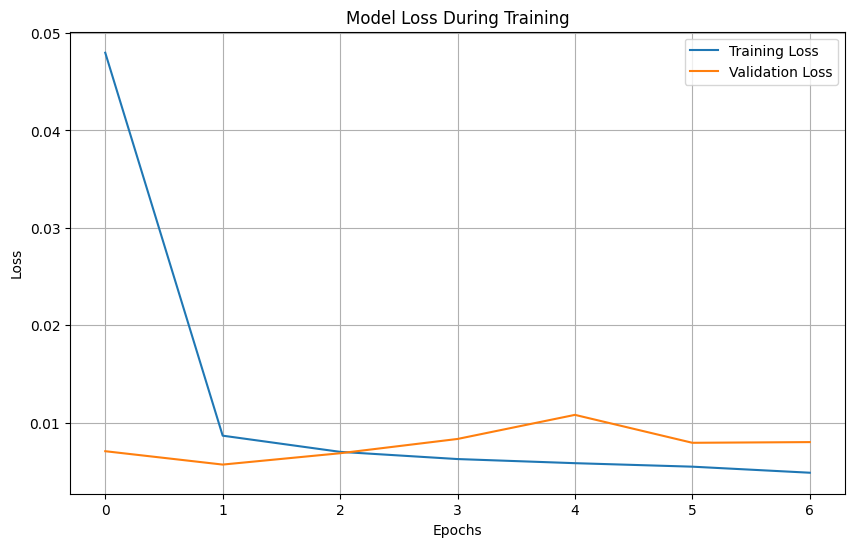

In [207]:
## 🪟 Create 60-Day Sequences
def create_sequences(data, window_size=60):
    X, y = [], []
    for i in range(window_size, len(data)):
        X.append(data[i-window_size:i])
        y.append(data[i, 3])  # Predict 'Close' column (index 3)
    return np.array(X), np.array(y)

x_train, y_train = create_sequences(train_data)
x_val, y_val = create_sequences(val_data)
x_test, y_test = create_sequences(test_data)

## 🔄 Reshape for LSTM
x_train = np.reshape(x_train, (x_train.shape[0], x_train.shape[1], x_train.shape[2]))
x_val = np.reshape(x_val, (x_val.shape[0], x_val.shape[1], x_val.shape[2]))
x_test = np.reshape(x_test, (x_test.shape[0], x_test.shape[1], x_test.shape[2]))

## 🧠 Build Enhanced LSTM Model
model = Sequential([
    Input(shape=(x_train.shape[1], x_train.shape[2])),
    Bidirectional(LSTM(128, return_sequences=True)),
    Dropout(0.5),
    LSTM(64),
    Dropout(0.2),
    Dense(25),
    Dense(1)
])
model.compile(optimizer='adam', loss='mean_squared_error')
## ⏳ Callbacks
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
model_save = ModelCheckpoint('best_model.h5', monitor='val_loss', save_best_only=True)
lr_schedule = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-5)
## 🎯 Train the Model
history = model.fit(
    x_train, y_train,
    epochs=50,
    batch_size=32,
    validation_data=(x_val, y_val),
    callbacks=[early_stop, model_save, lr_schedule],
    verbose=1
)
## 📈 Loss Curves
plt.figure(figsize=(10,6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss During Training')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid()
plt.show()
## 💾 Load Best Model
model = load_model('best_model.h5')

14/14 ━━━━━━━━━━━━━━━━━━━━ 4s 238ms/step
Test RMSE: 15.76
Test MAPE: 6.29%


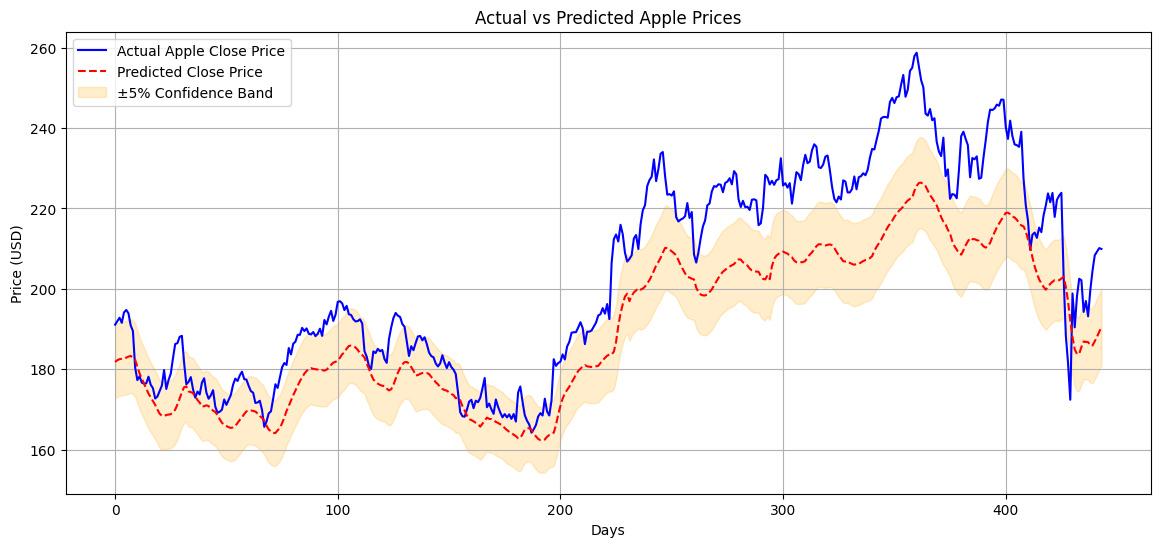

In [208]:
## 🧪 Predict & Evaluate
predictions = model.predict(x_test)
predicted_prices = scaler.inverse_transform(np.hstack([np.zeros((predictions.shape[0], 3)), predictions, np.zeros((predictions.shape[0], 1))]))[:,3]
y_test_actual = scaler.inverse_transform(np.hstack([np.zeros((y_test.shape[0], 3)), y_test.reshape(-1, 1), np.zeros((y_test.shape[0], 1))]))[:,3]

rmse = np.sqrt(mean_squared_error(y_test_actual, predicted_prices))
mape = np.mean(np.abs((y_test_actual - predicted_prices) / y_test_actual)) * 100
print(f"Test RMSE: {rmse:.2f}")
print(f"Test MAPE: {mape:.2f}%")


plt.figure(figsize=(14,6))
plt.plot(y_test_actual, label='Actual Apple Close Price', color='blue')
plt.plot(predicted_prices, label='Predicted Close Price', color='red', linestyle='--')
plt.fill_between(range(len(predicted_prices)),
                 predicted_prices - 0.05 * predicted_prices,
                 predicted_prices + 0.05 * predicted_prices,
                 color='orange', alpha=0.2, label='±5% Confidence Band')
plt.title('Actual vs Predicted Apple Prices')
plt.xlabel('Days')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid()
plt.show()

In [209]:
import plotly.graph_objects as go
import numpy as np

# Create x-axis values (e.g., time steps or days)
x_values = list(range(len(y_test_actual)))

# Create Plotly figure
fig = go.Figure()

# Actual prices trace
fig.add_trace(go.Scatter(
    x=x_values,
    y=y_test_actual,
    mode='lines',
    name='Actual Apple Close Price',
    line=dict(color='blue')
))

# Predicted prices trace
fig.add_trace(go.Scatter(
    x=x_values,
    y=predicted_prices,
    mode='lines',
    name='Predicted Close Price',
    line=dict(color='red', dash='dash')
))

# Confidence interval (±5%) shaded area
fig.add_trace(go.Scatter(
    x=x_values + x_values[::-1],  # combine forward and reverse x for fill
    y=(predicted_prices + 0.05 * predicted_prices).tolist() +
      (predicted_prices - 0.05 * predicted_prices)[::-1].tolist(),
    fill='toself',
    fillcolor='rgba(255,165,0,0.2)',
    line=dict(color='rgba(255,255,255,0)'),
    hoverinfo="skip",
    name='±5% Confidence Band'
))

# Layout and interactivity
fig.update_layout(
    title='Actual vs Predicted Apple Prices (Interactive)',
    xaxis_title='Days',
    yaxis_title='Price (USD)',
    hovermode='x unified',
    template='plotly_white',
    legend=dict(x=0, y=1.1, orientation='h')
)

# Show interactive plot
fig.show()


Epoch 1/50
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 212ms/step - loss: 0.1248

46/46 ━━━━━━━━━━━━━━━━━━━━ 20s 258ms/step - loss: 0.1232 - val_loss: 0.0071 - learning_rate: 0.0010
Epoch 2/50
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 176ms/step - loss: 0.0095

46/46 ━━━━━━━━━━━━━━━━━━━━ 18s 206ms/step - loss: 0.0095 - val_loss: 0.0057 - learning_rate: 0.0010
Epoch 3/50
46/46 ━━━━━━━━━━━━━━━━━━━━ 11s 212ms/step - loss: 0.0072 - val_loss: 0.0069 - learning_rate: 0.0010
Epoch 4/50
46/46 ━━━━━━━━━━━━━━━━━━━━ 11s 235ms/step - loss: 0.0060 - val_loss: 0.0083 - learning_rate: 0.0010
Epoch 5/50
46/46 ━━━━━━━━━━━━━━━━━━━━ 26s 350ms/step - loss: 0.0066 - val_loss: 0.0108 - learning_rate: 0.0010
Epoch 6/50
46/46 ━━━━━━━━━━━━━━━━━━━━ 14s 200ms/step - loss: 0.0058 - val_loss: 0.0079 - learning_rate: 5.0000e-04
Epoch 7/50
46/46 ━━━━━━━━━━━━━━━━━━━━ 12s 241ms/step - loss: 0.0049 - val_loss: 0.0080 - learning_rate: 5.0000e-04


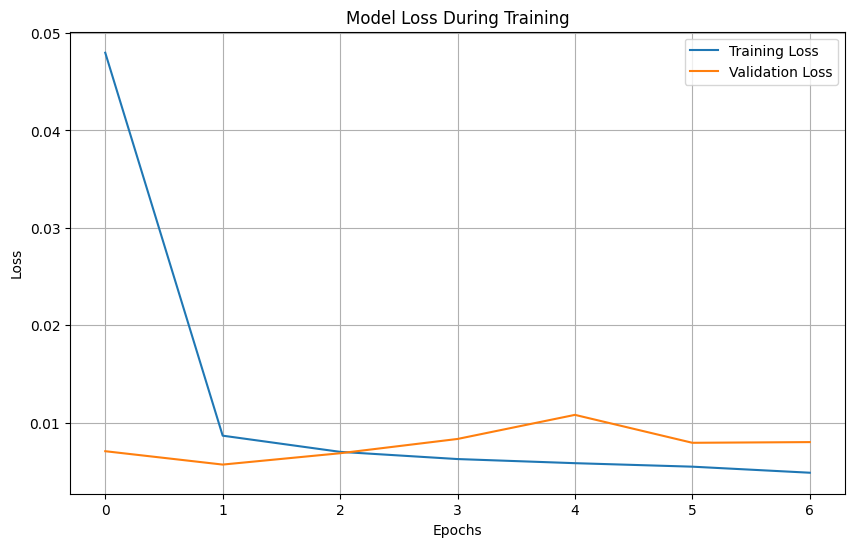

In [ ]:
## 🪟 Create 60-Day Sequences
def create_sequences(data, window_size=60):
    X, y = [], []
    for i in range(window_size, len(data)):
        X.append(data[i-window_size:i])
        y.append(data[i, 3])  # Predict 'Close' column (index 3)
    return np.array(X), np.array(y)

x_train, y_train = create_sequences(train_data)
x_val, y_val = create_sequences(val_data)
x_test, y_test = create_sequences(test_data)

## 🔄 Reshape for LSTM
x_train = np.reshape(x_train, (x_train.shape[0], x_train.shape[1], x_train.shape[2]))
x_val = np.reshape(x_val, (x_val.shape[0], x_val.shape[1], x_val.shape[2]))
x_test = np.reshape(x_test, (x_test.shape[0], x_test.shape[1], x_test.shape[2]))

## 🧠 Build Enhanced LSTM Model
model = Sequential([
    Input(shape=(x_train.shape[1], x_train.shape[2])),
    Bidirectional(LSTM(128, return_sequences=True)),
    Dropout(0.5),
    LSTM(64),
    Dropout(0.2),
    Dense(25),
    Dense(1)
])
model.compile(optimizer='adam', loss='mean_squared_error')
## ⏳ Callbacks
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
model_save = ModelCheckpoint('best_model.h5', monitor='val_loss', save_best_only=True)
lr_schedule = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-5)
## 🎯 Train the Model
history = model.fit(
    x_train, y_train,
    epochs=50,
    batch_size=32,
    validation_data=(x_val, y_val),
    callbacks=[early_stop, model_save, lr_schedule],
    verbose=1
)
## 📈 Loss Curves
plt.figure(figsize=(10,6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss During Training')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid()
plt.show()
## 💾 Load Best Model
model = load_model('best_model.h5')